### Minhash con PySpark

In [1]:
import pyspark
# Carga ufnciones extra
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('minhash').getOrCreate()

# Minhash y texto
from pyspark.ml.feature import MinHashLSH
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import CountVectorizer
from pyspark.sql.functions import col, size
import string
import nltk
nltk.download('stopwords')

# Graficar
import seaborn as sns

24/04/13 11:12:06 WARN Utils: Your hostname, vania-Latitude-7400 resolves to a loopback address: 127.0.1.1; using 10.153.221.214 instead (on interface wlo1)
24/04/13 11:12:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/04/13 11:12:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
[nltk_data] Downloading package stopwords to /home/vania/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Podemos definir vectores dispersos en PySpark usando estos parametros de la siguiente manera

In [2]:
vector = Vectors.sparse(10, [0, 5, 8], [1, 3, 2])
vector.toArray()

array([1., 0., 0., 0., 0., 3., 0., 0., 2., 0.])



Podemos crear un DataFrame con vectores dispersos de la siguiente manera


In [3]:
matriz_dispersa = [(Vectors.sparse(6, [0, 1, 2], [1.0, 1.0, 1.0]),),
                   (Vectors.sparse(6, [2, 3, 4], [1.0, 1.0, 1.0]),),
                   (Vectors.sparse(6, [0, 2, 4], [1.0, 1.0, 1.0]),)]

matriz_dispersa = spark.createDataFrame(matriz_dispersa)

matriz_dispersa.show()

+--------------------+
|                  _1|
+--------------------+
|(6,[0,1,2],[1.0,1...|
|(6,[2,3,4],[1.0,1...|
|(6,[0,2,4],[1.0,1...|
+--------------------+



In [4]:
documentos = spark.createDataFrame([(0, 'a,b,b,c'.split(',')),
                                    (1, 'b,c,d'.split(',')),
                                    (2, 'a,c'.split(','))],
                                   ['id', 'palabras'])

documentos.show()

+---+------------+
| id|    palabras|
+---+------------+
|  0|[a, b, b, c]|
|  1|   [b, c, d]|
|  2|      [a, c]|
+---+------------+



In [5]:
cv = CountVectorizer(inputCol  = 'palabras', 
                     outputCol = 'features', 
                     vocabSize = 6, 
                     minDF     = 1)

modelo = cv.fit(documentos)
mat_rep = modelo.transform(documentos)

mat_rep.show(truncate = False)

+---+------------+-------------------------+
|id |palabras    |features                 |
+---+------------+-------------------------+
|0  |[a, b, b, c]|(4,[0,1,2],[1.0,2.0,1.0])|
|1  |[b, c, d]   |(4,[0,1,3],[1.0,1.0,1.0])|
|2  |[a, c]      |(4,[0,2],[1.0,1.0])      |
+---+------------+-------------------------+



#### Datos

Los datos que usaremos son de la serie Rick y Morty. Corresponde a transcripciones de los dialogos de los personajes. La base de datos cuenta con los siguientes campos:

    Indice (Identificadore unico del renglon en la base de datos)
    Temporada
    Numero de episodio
    Nombre del episodio
    Linea de dialogo

Carguemos los datos en un DataFrame de PySpark

In [6]:
df_rym = spark.read.csv('content/RickAndMortyScripts.csv', header = True, inferSchema = True)

In [7]:
df_rym.printSchema()

root
 |-- index: integer (nullable = true)
 |-- season no.: integer (nullable = true)
 |-- episode no.: integer (nullable = true)
 |-- episode name: string (nullable = true)
 |-- name: string (nullable = true)
 |-- line: string (nullable = true)



In [8]:
df_rym.show(5)

+-----+----------+-----------+------------+-----+--------------------+
|index|season no.|episode no.|episode name| name|                line|
+-----+----------+-----------+------------+-----+--------------------+
|    0|         1|          1|       Pilot| Rick|Morty! You gotta ...|
|    1|         1|          1|       Pilot|Morty|What, Rick? What’...|
|    2|         1|          1|       Pilot| Rick|I got a surprise ...|
|    3|         1|          1|       Pilot|Morty|It's the middle o...|
|    4|         1|          1|       Pilot| Rick|Come on, I got a ...|
+-----+----------+-----------+------------+-----+--------------------+
only showing top 5 rows



Para fines del analisis que llevaremos a cabo en este notebook solo haremos uso del as columnas del nombre y el dialogo del personaje

In [9]:
df_rym = df_rym.select('index', 'name', 'line')
df_rym.show(5)

+-----+-----+--------------------+
|index| name|                line|
+-----+-----+--------------------+
|    0| Rick|Morty! You gotta ...|
|    1|Morty|What, Rick? What’...|
|    2| Rick|I got a surprise ...|
|    3|Morty|It's the middle o...|
|    4| Rick|Come on, I got a ...|
+-----+-----+--------------------+
only showing top 5 rows



Para hacer aun mas simple el analisis quedemonos solo con los dialogos de los personajes principales

In [10]:
personajes_principales = ['Rick', 'Morty', 'Beth', 'Jerry', 'Summer']
df_rym = df_rym.where(df_rym.name.isin(personajes_principales))

Revisemos la distribucion de dialogos de los personajes que tienen mas dialogos

<AxesSubplot:xlabel='name', ylabel='count'>

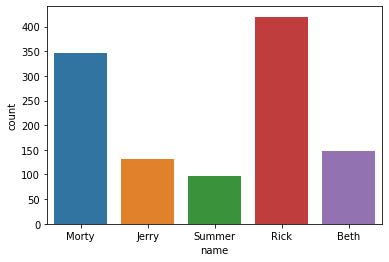

In [11]:
df_dist_dialog = df_rym.groupBy('name') \
                       .count() \
                       .toPandas()

sns.barplot( x = 'name', 
             y = 'count', 
             data = df_dist_dialog)

#### Preprocesamiento de los datos

##### Limpieza del texto



Aqui realizaremos el proceso que ya hemos hecho anteriormente, el cual consiste en:

    Transformar todo el texto a minusculas
    Eliminar signos de puntuacion
    Eliminar las palabras vacias, que son palabras que aportan poco contexto al problema

Veamos como se encuentra el texto originalmente

In [12]:
df_rym.limit(3) \
      .toPandas() \
      .loc[0:3, 'line']

0    Morty! You gotta come on. Jus'... you gotta co...
1                         What, Rick? What’s going on?
2                     I got a surprise for you, Morty.
Name: line, dtype: object

In [13]:
# Hacemos minusculas
df_rym = df_rym.rdd \
               .map(lambda x: (x[0], x[1], x[2].lower())) \
               .toDF(['id', 'nombre', 'dialog']) 

# Vemos como va el proceso
df_rym.limit(3) \
      .toPandas() \
      .loc[0:3,'dialog']

0    morty! you gotta come on. jus'... you gotta co...
1                         what, rick? what’s going on?
2                     i got a surprise for you, morty.
Name: dialog, dtype: object

In [14]:
# Elimina signos de puntacion
df_rym = df_rym.rdd \
           .map(lambda x: (x[0], x[1], x[2].translate(str.maketrans('', '', string.punctuation)))) \
           .toDF(['id', 'nombre', 'dialog']) 

# Vemos como va el proceso
df_rym.limit(3) \
      .toPandas() \
      .loc[0:3,'dialog']

0    morty you gotta come on jus you gotta come wit...
1                            what rick what’s going on
2                       i got a surprise for you morty
Name: dialog, dtype: object

Quitar stop words

In [15]:
# Definimos funcion para quitar stop words
palabras_vacias = nltk.corpus.stopwords.words('english')

def quita_palabras_vacias(texto):
  texto_limpio = [ palabra for palabra in texto if palabra not in palabras_vacias ]
  return texto_limpio

# Quitamos stop words
df_rym = df_rym.rdd \
           .map(lambda x: (x[0], x[1], x[2].split(' '))) \
           .map(lambda x: (x[0], x[1], quita_palabras_vacias(x[2]))) \
           .toDF(['id', 'nombre', 'dialog']) \
           .filter(size('dialog') > 0) # Elimina texto vacio

# Vemos como va el proceso
df_rym.limit(7) \
      .toPandas() \
      .loc[0:7,'dialog']

0               [morty, gotta, come, jus, gotta, come]
1                                [rick, what’s, going]
2                               [got, surprise, morty]
3                             [middle, night, talking]
4                 [come, got, surprise, , come, hurry]
5                       [ow, ow, youre, tugging, hard]
6    [gotta, go, gotta, get, outta, come, got, surp...
Name: dialog, dtype: object

#### Matriz de representacion

Ahora necesitamos representar los datos como una matriz de representacion, la cual nos dice que elementos del vocabulario aparecen en cada elemento del conjunto de datos.

In [16]:
cv = CountVectorizer(inputCol  = 'dialog', 
                     outputCol = 'features',
                     binary    = True, # Solo llena con 0 o 1
                     vocabSize = 3000,  # Tamano maximo del vocabulario 
                     minDF     = 1)    # En cuantos docs diferentes debe
                                       # aparecer una palabra para ser 
                                       # considerada para el vocabulario

In [17]:
# Calculamos el vocabulario dados los datos
matriz_representacion = cv.fit(df_rym)
# Traducimos los datos la matriz de representacion
df_rym_mr = matriz_representacion.transform(df_rym)
# Mustramos
df_rym_mr.show(10)

+---+------+--------------------+--------------------+
| id|nombre|              dialog|            features|
+---+------+--------------------+--------------------+
|  0|  Rick|[morty, gotta, co...|(2442,[0,24,101,1...|
|  1| Morty|[rick, what’s, go...|(2442,[3,40,353],...|
|  2|  Rick|[got, surprise, m...|(2442,[0,17,325],...|
|  3| Morty|[middle, night, t...|(2442,[65,113,116...|
|  4|  Rick|[come, got, surpr...|(2442,[1,17,24,32...|
|  5| Morty|[ow, ow, youre, t...|(2442,[7,171,570,...|
|  6|  Rick|[gotta, go, gotta...|(2442,[0,5,12,17,...|
|  7|  Rick|[think, flying, v...|(2442,[0,20,110,3...|
|  8| Morty|[yeah, rick, iits...|(2442,[3,14,129,3...|
|  9|  Rick|[morty, had—, to—...|(2442,[0,44,198,6...|
+---+------+--------------------+--------------------+
only showing top 10 rows



#### Minhash y distancia de Jaccard

Para crear un modelo basado en Minhashing hacemos lo siguiente

In [18]:
minhash = MinHashLSH(inputCol      = 'features', 
                     outputCol     = 'hashes', 
                     numHashTables = 100)

modelo_mh = minhash.fit(df_rym_mr)

Podemos mostrar como se ve la signature matrix creada a partir de la matriz de representacion

In [19]:
df_rym_mh = modelo_mh.transform(df_rym_mr) 

df_rym_mh.limit(10) \
         .show()

+---+------+--------------------+--------------------+--------------------+
| id|nombre|              dialog|            features|              hashes|
+---+------+--------------------+--------------------+--------------------+
|  0|  Rick|[morty, gotta, co...|(2442,[0,24,101,1...|[[4.07343899E8], ...|
|  1| Morty|[rick, what’s, go...|(2442,[3,40,353],...|[[9.95040342E8], ...|
|  2|  Rick|[got, surprise, m...|(2442,[0,17,325],...|[[7.79543557E8], ...|
|  3| Morty|[middle, night, t...|(2442,[65,113,116...|[[9.40381418E8], ...|
|  4|  Rick|[come, got, surpr...|(2442,[1,17,24,32...|[[7.79543557E8], ...|
|  5| Morty|[ow, ow, youre, t...|(2442,[7,171,570,...|[[1.059115999E9],...|
|  6|  Rick|[gotta, go, gotta...|(2442,[0,5,12,17,...|[[6.63947887E8], ...|
|  7|  Rick|[think, flying, v...|(2442,[0,20,110,3...|[[2.23537584E8], ...|
|  8| Morty|[yeah, rick, iits...|(2442,[3,14,129,3...|[[7.79543557E8], ...|
|  9|  Rick|[morty, had—, to—...|(2442,[0,44,198,6...|[[1.60458004E8], ...|
+---+------+

#### Similitud entre lineas

Podemos calcular las distancias entre los elementos de dos dataframes

In [20]:
similitud_entre_lineas = modelo_mh.approxSimilarityJoin(datasetA  = df_rym_mh,  
                                                      datasetB  = df_rym_mh, 
                                                      threshold = 0.5, 
                                                      distCol   = 'dist_jaccard') \
                                    .select(col('datasetA.nombre').alias('nombre_1'), 
                                        col('datasetB.nombre').alias('nombre_2'), 
                                        col('dist_jaccard')) \
                                    .where(col('dist_jaccard') > 0) # Quitamos las que son iguales

similitud_entre_lineas.show(4)      

/home/vania/jupyter/jupyterenv/lib/python3.8/site-packages/pyspark/sql/context.py:125: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


+--------+--------+-------------------+
|nombre_1|nombre_2|       dist_jaccard|
+--------+--------+-------------------+
|   Morty|   Morty|0.33333333333333337|
|    Rick|    Rick| 0.4285714285714286|
|  Summer|   Morty|0.33333333333333337|
|   Morty|   Jerry|0.33333333333333337|
+--------+--------+-------------------+
only showing top 4 rows



Veamos cuantas si pudimos identificar los dialogos por personaje

<AxesSubplot:xlabel='coinciden', ylabel='count'>

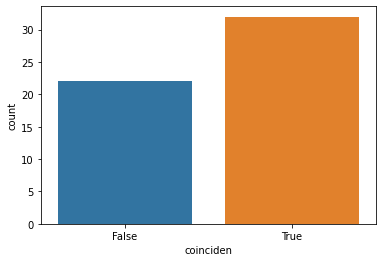

In [22]:
coincidencias = similitud_entre_lineas.withColumn('coinciden', 
                                                    col('nombre_1') == col('nombre_2')) \
                                        .groupBy('coinciden') \
                                        .count() \
                                        .toPandas()

sns.barplot( x    = 'coinciden', 
             y    = 'count', 
             data = coincidencias)

#### Vecinos mas cercanos

Calculamos los elementos mas cercanos a un elemento dado.

Extraemos una linea correspondinete a Morty

In [23]:
[renglon] = df_rym_mr.where(df_rym_mr.id == 170).collect()
print(renglon)
linea = renglon[3]
print(linea)

Row(id=170, nombre='Morty', dialog=['oh', 'geez', 'rick', 'really', 'dont', 'want'], features=SparseVector(2442, {2: 1.0, 3: 1.0, 9: 1.0, 18: 1.0, 33: 1.0, 64: 1.0}))
(2442,[2,3,9,18,33,64],[1.0,1.0,1.0,1.0,1.0,1.0])


Buscamos los elementos mas cercanos

In [24]:
vecinos_cercanos = modelo_mh.approxNearestNeighbors(dataset             = df_rym_mh, 
                                                    key                 = linea, 
                                                    numNearestNeighbors = 50, 
                                                    distCol             = 'dist_jaccard') \
                            .where(col('dist_jaccard') > 0) # Quitamos la linea repetida

/home/vania/jupyter/jupyterenv/lib/python3.8/site-packages/pyspark/sql/context.py:125: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Veamos cuantas lineas corresponden a cada personaje

In [25]:
vecinos_cercanos_hist = vecinos_cercanos.groupby('nombre') \
                                        .count() \
                                        .toPandas()

<AxesSubplot:xlabel='nombre', ylabel='count'>

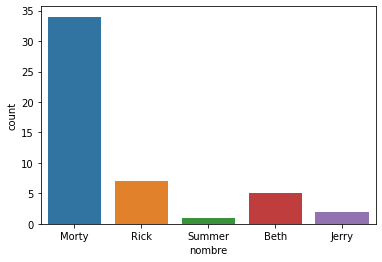

In [26]:
sns.barplot( x    = 'nombre', 
             y    = 'count', 
             data = vecinos_cercanos_hist)

### Ejercicio

Haga alguna variacion del problema aqui presentado y explique sus resultados. Algunas de las cosas que podria hacer son:

    Cambiar el conjutno de personajes considerados.
    Cambiar al en el la limpieza de datos, no quitar stopwords, etc.
    Cambrias los hiperparametros de los objetos CountVectorizer, MinHashLSH, etc.
    Usar otra linea para los vecinos mas cercanos, etc.
